<a href="https://colab.research.google.com/github/mdonbruce/AspNetDocs/blob/master/Lab1_Animals_Inheritance_Instructor_EXECUTED.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 1 — Creature Kingdom: Instructor EXECUTED

Complete solution with example outputs.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path
DATA_FILE = Path("lab1_animals.csv")
if not DATA_FILE.exists():
    DATA_FILE = Path(r"/mnt/data/module3_inheritance_polymorphism/lab1_animals.csv")
print("Using:", DATA_FILE.resolve())

df = pd.read_csv(DATA_FILE)
df.head()

Matplotlib is building the font cache; this may take a moment.


Using: /mnt/data/module3_inheritance_polymorphism/lab1_animals.csv


,animal_id,species,taxon,diet,habitat,weight_kg,speed_kmh,lifespan_years,endangered,daily_food_kg
0,1,Honeybee,Insect,Nectarivore,Wetlands,28.73,23.1,37,N,0.713
1,2,Elephant,Mammal,Herbivore,Meadow,16.99,9.6,18,N,0.470
2,3,Lion,Mammal,Carnivore,River,19.16,39.8,15,N,1.015
3,4,Salmon,Fish,Omnivore,Savanna,9.37,42.1,44,N,0.346
4,5,Penguin,Bird,Carnivore,Tundra,43.67,22.2,43,N,2.253


In [ ]:
print(df.shape)
df.isna().sum().head()

(25000, 10)


animal_id    0
species      0
taxon        0
diet         0
habitat      0
dtype: int64

In [ ]:
class Animal:
    def __init__(self, species, weight_kg, diet):
        self.species = species
        self.weight_kg = float(weight_kg)
        self.diet = diet

    def base_factor(self):
        return {
            'Carnivore': 0.050,
            'Herbivore': 0.035,
            'Omnivore': 0.040,
            'Insectivore': 0.030,
            'Nectarivore': 0.020,
        }.get(self.diet, 0.04)

    def daily_food_needed(self):
        return max(0.01, self.weight_kg * self.base_factor())

class Mammal(Animal):
    def daily_food_needed(self):
        # mammals slightly higher metabolism
        return super().daily_food_needed() * 1.08

class Bird(Animal):
    def daily_food_needed(self):
        # birds: lower absolute but higher per kg; simple tweak
        return super().daily_food_needed() * 0.95

class Reptile(Animal):
    def daily_food_needed(self):
        # reptiles often lower metabolism
        return super().daily_food_needed() * 0.75


In [ ]:
def make_animal(row):
    cls = row['taxon']
    if cls == 'Mammal':
        return Mammal(row['species'], row['weight_kg'], row['diet'])
    if cls == 'Bird':
        return Bird(row['species'], row['weight_kg'], row['diet'])
    if cls == 'Reptile':
        return Reptile(row['species'], row['weight_kg'], row['diet'])
    # fallback
    return Animal(row['species'], row['weight_kg'], row['diet'])


In [ ]:
sample = df.sample(3000, random_state=42)
animals = [make_animal(r) for _, r in sample.iterrows()]
food = np.array([a.daily_food_needed() for a in animals])
food.mean(), food.min(), food.max()

(1.1386618346666668, 0.0926, 7.09555)

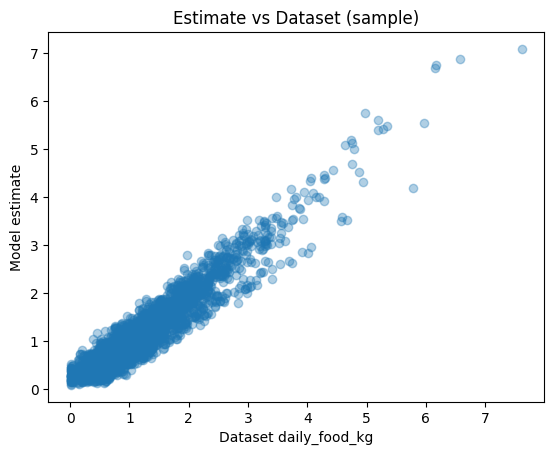

In [ ]:
plt.figure()
plt.scatter(sample['daily_food_kg'], food, alpha=0.35)
plt.xlabel('Dataset daily_food_kg')
plt.ylabel('Model estimate')
plt.title('Estimate vs Dataset (sample)')
plt.show()

In [ ]:
by_taxon = sample.assign(estimate=food).groupby('taxon')[['daily_food_kg','estimate']].mean()
by_taxon

,daily_food_kg,estimate
taxon,,
Amphibian,0.867121,0.856869
Bird,1.446094,1.371765
Fish,1.141813,1.158160
Insect,0.581020,0.575441
Mammal,1.330666,1.447142
Reptile,1.182688,0.883833
